# 09. Gait JEPA as a world model: latent future prediction and predictive surprise

**Direction supported:** *"Imagining the Next Step"* — Direction A of `docs/neurips-brain-body.md`,
the **primary workshop framing** (BrainBodyFM 2026 emphasizes "the motor side of the loop"). This
notebook needs **no training at all**: it re-purposes the frozen S-JEPA checkpoints as a *world model
of body movement* and measures how much of the future the model can imagine in latent space.

## The idea in one paragraph

The JEPA-as-world-model thesis (LeCun 2022) says a good predictive model should be able to *plan and
simulate* in representation space. The gavd5-drift S-JEPA was trained for exactly one job: **spatial
infilling** — hide some joint-time tokens inside a clip, predict their latent states from the rest of
the *same* clip (full bidirectional temporal context). It was explicitly *not* trained to forecast.

Here we **flip the mask axis**: hide **all 33 joints of the last `h` time patches** (the future),
show only the past, and ask the frozen predictor to *imagine the next body states*. The EMA target
encoder, which sees the complete clip, supplies the ground-truth latents. The gap between imagined
and actual future — **predictive surprise** — is then scored per condition.

**Both outcomes are a contribution.** If surprise grows with pathology, latent forward dynamics
emerged from an infilling objective, and surprise becomes a new *motor biosignal* with links to
predictive-processing accounts of motor control. If it does not (and infilling does not transfer to
forecasting), we establish a sharp empirical boundary the world-model literature currently assumes
away — and justify causal/action-conditioned JEPA variants (A-JEPA/H-JEPA style) for biosignals.

## Claim discipline (unchanged)

* The source video is the independent unit: condition-level inference below is performed on
  **video-level** aggregates (35 videos), not on 159 pseudoreplicated clips.
* The frozen encoder is transductive (it saw every row). This is an *in-corpus* mechanistic study.
* Folder labels are dataset annotations, not diagnoses.

**Research use only.** Nothing here diagnoses a person or validates a clinical device.


In [1]:
from pathlib import Path
import os
import sys
import math

# --- Robust project-layout resolution -------------------------------------
NOTEBOOK_DIR = Path.cwd().resolve()
if not (NOTEBOOK_DIR / "work").exists() and os.getenv("ALEXPOSE_ROOT"):
    NOTEBOOK_DIR = (
        Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        / "experiments" / "sjepa" / "gavd5-drift"
    )
if not (NOTEBOOK_DIR / "work").exists():
    raise FileNotFoundError(
        f"Cannot locate the gavd5-drift project folder from {NOTEBOOK_DIR}. "
        "Run this notebook from experiments/sjepa/gavd5-drift or set ALEXPOSE_ROOT."
    )

MODE = os.environ.setdefault("GAVD_MODE", "real").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be smoke or real")
if MODE == "smoke":
    print("SMOKE MODE: hand-authored motions test code paths only.")

CACHE_DIR = Path(
    os.environ.setdefault("GAVD_CACHE_DIR", str(NOTEBOOK_DIR / "cache"))
).expanduser()
ARTIFACT_ROOT = Path(
    os.environ.setdefault(
        "GAVD_ARTIFACT_DIR", str(NOTEBOOK_DIR / "work" / "artifacts")
    )
).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"

INCLUDE_AUGMENTED_NORMAL = os.environ.setdefault(
    "SJEPA_INCLUDE_AUGMENTED_NORMAL", "0"
).strip().lower() in {"1", "true", "yes", "on"}

for folder in [CACHE_DIR, ARTIFACT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd

print(f"mode: {MODE}")
print(f"artifacts: {ARTIFACT_DIR}")
print("augmentation-normal cohort: "
      + ("ENABLED (additive)" if INCLUDE_AUGMENTED_NORMAL else "disabled"))


mode: real
artifacts: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real
augmentation-normal cohort: disabled


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [3]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


In [4]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    # Fill only short internal gaps and preserve the original validity mask.
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames=64, visibility_threshold=0.45, max_gap=4):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [5]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored = str(data["condition"].item())
            if stored != condition:
                raise ValueError(
                    f"Pose condition {stored} does not match folder {condition}"
                )
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, frames=64):
    if MODE == "smoke":
        raise NotImplementedError("This notebook is designed for the real corpus.")
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [c for c in conditions if counts.get(c, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= 0.45
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "cohort": "augmented_normal",
            "sequence": data["sequence"].astype(np.float32),
            "path": str(path),
        })
    return records


## Step 1. Load the frozen final encoder (same lineage contract as notebooks 06/07)


In [6]:
import hashlib

FINAL_CHECKPOINT = ARTIFACT_DIR / "sjepa_curriculum_final_augmented.pt"
if not FINAL_CHECKPOINT.is_file():
    raise FileNotFoundError(
        f"Missing {FINAL_CHECKPOINT}. Run notebook 04 first (real mode, augmented normal)."
    )
FILE_SHA256 = hashlib.sha256(FINAL_CHECKPOINT.read_bytes()).hexdigest()
checkpoint = torch.load(FINAL_CHECKPOINT, map_location="cpu", weights_only=False)

EXPECTED_FINGERPRINT_PREFIX = "d0acc2628d13"
EXPECTED_CURRICULUM = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]

if checkpoint["mode"] != MODE:
    raise ValueError("Checkpoint mode does not match this notebook")
if checkpoint["mask_keypoints"] != MASK_KEYPOINTS:
    raise ValueError("Checkpoint used a different mask keypoint set")
if not checkpoint.get("curriculum_complete", False):
    raise ValueError("Checkpoint is not the completed five-stage curriculum")
if checkpoint.get("conditions_seen") != EXPECTED_CURRICULUM:
    raise ValueError(f"Unexpected curriculum order: {checkpoint.get('conditions_seen')}")
fingerprint = checkpoint.get("dataset_fingerprint", "")
if not fingerprint.startswith(EXPECTED_FINGERPRINT_PREFIX):
    raise ValueError(
        f"Expected fingerprint prefix {EXPECTED_FINGERPRINT_PREFIX}, got {fingerprint}"
    )

config = checkpoint["config"]
model = SJEPAGait(**config)
model.load_state_dict(checkpoint["model_state"])
model.eval()
FRAMES = config["frames"]
SEGMENTS = FRAMES // config["segment_length"]
EMBED_DIM = config["embed_dim"]

print(f"checkpoint file SHA-256: {FILE_SHA256}")
print(f"experiment fingerprint:  {fingerprint}")
print(f"tokens per sequence: {SEGMENTS} x 33 = {SEGMENTS * 33}")


checkpoint file SHA-256: 2aa20dd4ac925698ee801687992cd998d24efa9bc38f9a9939e983e70f0cc398
experiment fingerprint:  d0acc2628d134959d8b91e96d5112fc3bed560fe8feb9569e5b13b11a8b614d1
tokens per sequence: 16 x 33 = 528


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/3878467626.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/3878467626.py:103: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=depth)


In [7]:
records = load_records_for_mode(conditions=CONDITIONS)
prepared = [prepare_sequence(r["sequence"], frames=FRAMES) for r in records]
all_xyz = np.stack([item[0] for item in prepared]).astype(np.float32)
all_valid = np.stack([item[1] for item in prepared])
sequence_ids = np.asarray([r["sequence_id"] for r in records])
video_ids = np.asarray([r["video_id"] for r in records])
labels = np.asarray([r["condition"] for r in records])
# Full-corpus QC: keep only sequences with sufficient neurologic coverage AND at
# least two valid authorized time-patches (matches notebook 04's training filter),
# so predictive-surprise helpers never sample from an empty eligible-token set.
_min_cov = float(os.getenv("GAVD_MIN_NEURO_COVERAGE", "0.50"))
_cov = all_valid[:, :, MASK_KEYPOINTS].mean(axis=(1, 2))
_pv = all_valid.reshape(len(all_valid), all_valid.shape[1] // 4, 4, 33).all(axis=2)
_patches = _pv[:, :, MASK_KEYPOINTS].reshape(len(all_valid), -1).sum(axis=1)
_keep = (_cov >= _min_cov) & (_patches >= 2)
if not _keep.all():
    print(f"nb09: dropping {int((~_keep).sum())} low-coverage/degenerate sequences; "
          f"{int(_keep.sum())} retained.")
    all_xyz = all_xyz[_keep]; all_valid = all_valid[_keep]
    sequence_ids = sequence_ids[_keep]; video_ids = video_ids[_keep]; labels = labels[_keep]

aug_records = augmented_normal_records() if INCLUDE_AUGMENTED_NORMAL else []
if aug_records:
    aug_prepared = [prepare_sequence(r["sequence"], frames=FRAMES) for r in aug_records]
    aug_xyz = np.stack([item[0] for item in aug_prepared]).astype(np.float32)
    aug_valid = np.stack([item[1] for item in aug_prepared])
    aug_video_ids = np.asarray([r["video_id"] for r in aug_records])
else:
    aug_xyz = np.empty((0, FRAMES, 33, 3), dtype=np.float32)
    aug_valid = np.empty((0, FRAMES, 33), dtype=bool)
    aug_video_ids = np.empty((0,), dtype=object)

pooled_xyz = np.concatenate([all_xyz, aug_xyz], axis=0)
pooled_valid = np.concatenate([all_valid, aug_valid], axis=0)
pooled_videos = np.concatenate([video_ids, aug_video_ids])
pooled_labels = np.concatenate([labels, np.asarray(["normal"] * len(aug_records))])
print(f"pooled corpus: {len(pooled_xyz)} sequences, "
      f"{len(set(pooled_videos.tolist()))} source videos")


Real pose corpus: 642 sequences


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/2758118474.py:47: RuntimeWarning: All-NaN slice encountered
  body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))


nb09: dropping 16 low-coverage/degenerate sequences; 626 retained.
pooled corpus: 626 sequences, 93 source videos


## Step 2. Three mask geometries on one frozen predictor

For a sequence with 16 time patches (4 frames each), we evaluate three masks:

1. **future mask** (the world-model probe): hide all 33 joints in the last `h` patches;
2. **copy-last baseline**: the future latent equals the last past patch's latent for the same joint —
   the best a memoryless world model can do;
3. **spatial infilling ceiling** (in-distribution): hide a random 60% of *eligible* 12-landmark tokens
   across all patches, exactly like training — the model's native task at matched token counts.

All latents come from the frozen EMA target encoder; predictions come from the frozen predictor.
Quality is per-token cosine similarity; **surprise = 1 − cosine**.


In [8]:
def valid_patch_mask(validity):
    seg_len = FRAMES // SEGMENTS
    return np.asarray(validity, dtype=bool).reshape(
        len(validity), SEGMENTS, seg_len, 33
    ).all(axis=2)


vpatches = valid_patch_mask(pooled_valid)
print("valid patch mask:", vpatches.shape)


def run_masked_predictions(xyz_batch, target_mask_np):
    # Run the frozen model with an explicit [N,16,33] bool target mask.
    # Returns predicted latents [N, M, D] and target latents [N, M, D] plus the
    # [N,16,33] bool positions actually scored.
    target_mask = torch.tensor(target_mask_np, dtype=torch.bool)
    xyz = torch.tensor(xyz_batch, dtype=torch.float32)
    with torch.no_grad():
        predicted, selected = model(xyz, xyz, target_mask)
    return predicted, selected


def future_mask(horizon):
    # Hide all 33 joints of the last `horizon` time patches.
    mask = np.zeros((SEGMENTS, 33), dtype=bool)
    mask[SEGMENTS - horizon:, :] = True
    return mask


def future_cosines(xyz_batch, vpatches_batch, horizon):
    n = len(xyz_batch)
    fmask = np.tile(future_mask(horizon)[None], (n, 1, 1))
    predicted, selected = run_masked_predictions(xyz_batch, fmask)
    cos = torch.nn.functional.cosine_similarity(
        predicted, selected, dim=-1
    ).cpu().numpy()
    # reshape back to per-(patch, joint) for validity-gated aggregation
    out = np.full((n, SEGMENTS, 33), np.nan, dtype=np.float32)
    for i in range(n):
        pos = 0
        for t in range(SEGMENTS):
            for j in range(33):
                if fmask[i, t, j]:
                    out[i, t, j] = cos[i, pos]
                    pos += 1
    # validity gate: only score positions that were valid in the source clip
    gated = np.where(vpatches_batch & fmask, out, np.nan)
    per_seq = np.nanmean(gated, axis=(1, 2))
    return per_seq, gated


def copy_last_cosines(xyz_batch, vpatches_batch, horizon):
    # Future latent = last past patch latent of the same joint.
    n = len(xyz_batch)
    with torch.no_grad():
        tokens = model.target_encoder(
            torch.tensor(xyz_batch, dtype=torch.float32)
        ).reshape(n, SEGMENTS, 33, EMBED_DIM)
    last_past = tokens[:, SEGMENTS - horizon - 1, :, :]
    future = tokens[:, SEGMENTS - horizon:, :, :]
    cos = torch.nn.functional.cosine_similarity(
        last_past[:, None, :, :].expand_as(future), future, dim=-1
    ).cpu().numpy()
    gated = np.where(vpatches_batch[:, SEGMENTS - horizon:], cos, np.nan)
    return np.nanmean(gated, axis=(1, 2)), gated


def no_context_cosines(xyz_batch, vpatches_batch, horizon):
    # Predictor sees NO tokens at all (positional priors only).
    n = len(xyz_batch)
    fmask = np.tile(future_mask(horizon)[None], (n, 1, 1))
    # force every token hidden so the view encoder emits only zeros
    all_mask = np.ones_like(fmask)
    predicted, selected = run_masked_predictions(xyz_batch, all_mask)
    cos = torch.nn.functional.cosine_similarity(
        predicted, selected, dim=-1
    ).cpu().numpy()
    out = np.full((n, SEGMENTS, 33), np.nan, dtype=np.float32)
    for i in range(n):
        pos = 0
        for t in range(SEGMENTS):
            for j in range(33):
                if all_mask[i, t, j]:
                    out[i, t, j] = cos[i, pos]
                    pos += 1
    gated = np.where(vpatches_batch & fmask, out, np.nan)
    return np.nanmean(gated, axis=(1, 2)), gated


def spatial_ceiling_cosines(xyz_batch, vpatches_batch, fraction=0.6, seed=42):
    # In-distribution spatial infilling at a matched token count.
    n, s, j = vpatches_batch.shape
    eligible = np.zeros((n, s, 33), dtype=bool)
    eligible[:, :, MASK_KEYPOINTS] = vpatches_batch[:, :, MASK_KEYPOINTS]
    rng = np.random.default_rng(seed)
    per_seq = []
    for i in range(n):
        idx = np.flatnonzero(eligible[i].reshape(-1))
        if len(idx) == 0:
            per_seq.append(float("nan"))
            continue
        m = max(1, min(int(fraction * len(idx)), len(idx)))
        chosen = rng.choice(idx, size=m, replace=False)
        fmask = np.zeros((s, 33), dtype=bool)
        fmask.reshape(-1)[chosen] = True
        predicted, selected = run_masked_predictions(
            xyz_batch[i:i + 1], fmask[None]
        )
        cos = torch.nn.functional.cosine_similarity(
            predicted[0], selected[0], dim=-1
        ).cpu().numpy()
        per_seq.append(float(np.mean(cos)))
    return np.asarray(per_seq, dtype=np.float32)


print("mask machinery ready")


valid patch mask: (626, 16, 33)
mask machinery ready


## Step 3. Error-vs-horizon: does an infilling predictor forecast?

We run horizons `h ∈ {2, 4, 8}` (0.5 s, 1.0 s, 2.0 s of the 4-second resized clip) on the
**canonical 642 sequences** and compare against the copy-last baseline, the no-context floor, and the
spatial-infilling ceiling.


In [9]:
HORIZONS = [2, 4, 8]
horizon_rows = []
for h in HORIZONS:
    future_cos, _ = future_cosines(all_xyz, vpatches[:len(all_xyz)], h)
    copy_cos, _ = copy_last_cosines(all_xyz, vpatches[:len(all_xyz)], h)
    noctx_cos, _ = no_context_cosines(all_xyz, vpatches[:len(all_xyz)], h)
    ceiling = spatial_ceiling_cosines(all_xyz, vpatches[:len(all_xyz)], seed=42)
    for i in range(len(all_xyz)):
        horizon_rows.append({
            "horizon": h,
            "condition": labels[i],
            "video_id": video_ids[i],
            "future_cosine": float(future_cos[i]),
            "copy_last_cosine": float(copy_cos[i]),
            "no_context_cosine": float(noctx_cos[i]),
            "spatial_ceiling_cosine": float(ceiling[i]),
        })
horizon_table = pd.DataFrame(horizon_rows)
summary = horizon_table.groupby(["horizon", "condition"]).agg(
    future_cosine=("future_cosine", "mean"),
    copy_last_cosine=("copy_last_cosine", "mean"),
    no_context_cosine=("no_context_cosine", "mean"),
).reset_index()
print("Canonical 642: mean future-cosine vs baselines")
display(summary.pivot(index="condition", columns="horizon", values="future_cosine").round(3))
print("Copy-last baseline (h=4):")
display(horizon_table[horizon_table.horizon == 4].groupby("condition")[
    "copy_last_cosine"].mean().round(3))
print("Spatial-infilling ceiling (in-distribution): "
      f"{horizon_table['spatial_ceiling_cosine'].mean():.3f} (mean over conditions)")
horizon_table.to_csv(ARTIFACT_DIR / "predictive_surprise_horizons.csv", index=False)


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/4135085388.py:48: RuntimeWarning: Mean of empty slice
  per_seq = np.nanmean(gated, axis=(1, 2))


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/4135085388.py:65: RuntimeWarning: Mean of empty slice
  return np.nanmean(gated, axis=(1, 2)), gated


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/4135085388.py:87: RuntimeWarning: Mean of empty slice
  return np.nanmean(gated, axis=(1, 2)), gated


Canonical 642: mean future-cosine vs baselines


horizon,2,4,8
condition,,,
cerebralpalsy,0.293,0.292,0.267
myopathic,0.305,0.303,0.266
normal,0.365,0.347,0.296
parkinsons,0.402,0.374,0.306
stroke,0.377,0.366,0.329


Copy-last baseline (h=4):


condition
cerebralpalsy    0.930
myopathic        0.911
normal           0.901
parkinsons       0.944
stroke           0.926
Name: copy_last_cosine, dtype: float64

Spatial-infilling ceiling (in-distribution): 0.515 (mean over conditions)


## Step 4. Predictive surprise as a motor biosignal — scored at the video level

The honest unit here is the **source video**, not the clip. For each of the 35 videos we average the
per-sequence surprise at `h = 4` (surprise = 1 − future cosine). We then ask:

1. Do conditions differ in video-level surprise (Kruskal–Wallis)?
2. Does normal-vs-condition AUROC computed on **video-level** units exceed 0.5, with a cluster
   bootstrap confidence interval?
3. Controls: (a) does surprise merely track detector missingness (correlation + residualization),
   and (b) is there a provenance effect (canonical normal video vs the 17 added normal videos)?


In [10]:
from scipy import stats

H = 4
future_cos_pool, _ = future_cosines(pooled_xyz, vpatches, H)
surprise = 1.0 - future_cos_pool

frame = pd.DataFrame({
    "video_id": pooled_videos,
    "condition": pooled_labels,
    "surprise": surprise,
    "future_cosine": future_cos_pool,
})
video_level = frame.groupby("video_id").agg(
    condition=("condition", "first"),
    surprise=("surprise", "mean"),
    n_clips=("surprise", "size"),
).reset_index()
print("video-level surprise by condition:")
display(video_level.groupby("condition")["surprise"].agg(
    ["count", "median", "mean", "std"]).round(3))

groups = [g["surprise"].to_numpy() for _, g in video_level.groupby("condition")]
h_stat, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis across conditions (video-level): H={h_stat:.3f}, p={p_kw:.4g}")


def video_level_auroc(pos, neg, n_boot=2000, seed=0):
    # AUROC on video-level units with a bootstrap CI over videos.
    from sklearn.metrics import roc_auc_score
    rng = np.random.default_rng(seed)
    y = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
    s = np.concatenate([pos, neg])
    auroc = roc_auc_score(y, s)
    boots = []
    for _ in range(n_boot):
        pi = rng.integers(0, len(pos), len(pos))
        ni = rng.integers(0, len(neg), len(neg))
        yb = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
        sb = np.concatenate([pos[pi], neg[ni]])
        if len(np.unique(yb)) == 2:
            boots.append(roc_auc_score(yb, sb))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return auroc, float(lo), float(hi)


normal_surprise = video_level.loc[
    video_level.condition == "normal", "surprise"
].to_numpy()
normal_surprise = normal_surprise[np.isfinite(normal_surprise)]
auroc_rows = []
for cond in ["parkinsons", "stroke", "myopathic", "cerebralpalsy"]:
    s = video_level.loc[video_level.condition == cond, "surprise"].to_numpy()
    s = s[np.isfinite(s)]
    auroc, lo, hi = video_level_auroc(s, normal_surprise)
    auroc_rows.append({
        "comparison": f"normal_vs_{cond}",
        "auroc_video_level": float(auroc),
        "ci_low": lo,
        "ci_high": hi,
        "n_normal_videos": int(len(normal_surprise)),
        "n_condition_videos": int(len(s)),
    })
auroc_table = pd.DataFrame(auroc_rows)
display(auroc_table.round(3))
auroc_table.to_csv(ARTIFACT_DIR / "predictive_surprise_auroc.csv", index=False)

# Control (a): does surprise track detector missingness?
missing_fraction = 1.0 - pooled_valid.mean(axis=(1, 2))
finite_mask = np.isfinite(surprise) & np.isfinite(missing_fraction)
r_miss, p_miss = stats.spearmanr(
    surprise[finite_mask], missing_fraction[finite_mask]
)
print(f"sequence-level surprise vs missingness fraction: rho={r_miss:.3f}, p={p_miss:.4g}")
finite_mask = np.isfinite(surprise) & np.isfinite(missing_fraction)
rank_s = np.full(len(surprise), np.nan)
rank_s[finite_mask] = stats.rankdata(surprise[finite_mask])
rank_m = np.full(len(surprise), np.nan)
rank_m[finite_mask] = stats.rankdata(missing_fraction[finite_mask])
resid = rank_s - rank_m
video_resid = (
    pd.DataFrame({"video_id": pooled_videos, "resid": resid})
    .dropna()
    .groupby("video_id")["resid"]
    .mean()
)
video_level["resid"] = video_level["video_id"].map(video_resid)
normal_resid = video_level.loc[
    video_level.condition == "normal", "resid"
].to_numpy()
normal_resid = normal_resid[np.isfinite(normal_resid)]
print("AUROC after missingness residualization (video-level):")
for cond in ["parkinsons", "stroke", "myopathic", "cerebralpalsy"]:
    s = video_level.loc[video_level.condition == cond, "resid"].to_numpy()
    s = s[np.isfinite(s)]
    auroc, lo, hi = video_level_auroc(s, normal_resid)
    print(f"  normal_vs_{cond}: {auroc:.3f} [{lo:.3f}, {hi:.3f}]")

# Control (b): provenance effect among normal videos (canonical vs added path).
canonical_norm_ids = set(video_ids[labels == "normal"].tolist())
video_level["path"] = video_level["video_id"].apply(
    lambda v: "canonical" if v in canonical_norm_ids else "added_normal"
)
path_table = video_level[video_level.condition == "normal"].groupby("path")[
    "surprise"
].agg(["count", "median"])
display(path_table.round(3))


video-level surprise by condition:


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/4135085388.py:48: RuntimeWarning: Mean of empty slice
  per_seq = np.nanmean(gated, axis=(1, 2))


,count,median,mean,std
condition,,,,
cerebralpalsy,9,0.689,0.666,0.103
myopathic,28,0.653,0.640,0.109
normal,29,0.661,0.656,0.123
parkinsons,9,0.654,0.654,0.074
stroke,18,0.616,0.626,0.093


Kruskal-Wallis across conditions (video-level): H=1.986, p=0.7384


,comparison,auroc_video_level,ci_low,ci_high,n_normal_videos,n_condition_videos
0,normal_vs_parkinsons,0.502,0.303,0.705,29,9
1,normal_vs_stroke,0.408,0.247,0.567,29,18
2,normal_vs_myopathic,0.461,0.312,0.621,29,28
3,normal_vs_cerebralpalsy,0.548,0.345,0.751,29,9


...

  normal_vs_parkinsons: 0.559 [0.356, 0.755]


  normal_vs_stroke: 0.443 [0.276, 0.609]


  normal_vs_myopathic: 0.590 [0.437, 0.741]


  normal_vs_cerebralpalsy: 0.625 [0.414, 0.808]


,count,median
path,,
canonical,29,0.661


## Step 5. A two-step latent rollout (imagined futures)

A world model should be able to *iterate* its own predictions. As a minimal rollout demo we take one
canonical normal clip and chain two latent steps: first predict patch 14 from patches 0–13, then
predict patch 15 using the *predicted* latent of patch 14 in place of its observed feature — and
compare against the direct h=2 forecast. A large gap between direct and rolled-out cosine is the
signature of compounding prediction error, the classic failure mode of open-loop rollouts.


In [11]:
def latent_rollout_demo(xyz_one, vpatch_one):
    # Step 1: predict patch 14 given patches 0..13
    mask1 = np.zeros((SEGMENTS, 33), dtype=bool)
    mask1[14, :] = True
    predicted, selected = run_masked_predictions(xyz_one[None], mask1[None])
    p14 = predicted[0]  # [33, D]
    t14 = selected[0]
    cos_direct_14 = torch.nn.functional.cosine_similarity(
        p14, t14, dim=-1
    ).cpu().numpy()

    # Step 2: predict patch 15 given patches 0..13 plus the IMAGINED patch 14
    xyz_t = torch.tensor(xyz_one[None], dtype=torch.float32)
    mask2 = np.zeros((SEGMENTS, 33), dtype=bool)
    mask2[15, :] = True
    keep_mask2 = ~mask2.reshape(-1)
    with torch.no_grad():
        visible = model.view_encoder(xyz_t).reshape(1, SEGMENTS, 33, EMBED_DIM)
        # overwrite patch 14's visible features with the imagined latents
        visible[:, 14, :, :] = p14.reshape(1, 33, EMBED_DIM)
        # compact to visible positions only (the predictor's input contract)
        visible_comp = visible.reshape(1, SEGMENTS * 33, EMBED_DIM)[:, keep_mask2]
        pred15 = model.predictor(
            visible_comp, torch.tensor(mask2.reshape(1, -1), dtype=torch.bool)
        )
        t15 = model.target_encoder(xyz_t).reshape(1, SEGMENTS, 33, EMBED_DIM)[
            :, 15
        ]
    cos_rollout_15 = torch.nn.functional.cosine_similarity(
        pred15[0], t15[0], dim=-1
    ).cpu().numpy()

    # Direct h=2 reference for patch 15
    mask_h2 = np.zeros((SEGMENTS, 33), dtype=bool)
    mask_h2[14:, :] = True
    predicted2, selected2 = run_masked_predictions(xyz_one[None], mask_h2[None])
    cos_direct_15 = torch.nn.functional.cosine_similarity(
        predicted2[0][33:], selected2[0][33:], dim=-1
    ).cpu().numpy()

    return {
        "cos_direct_patch14": float(np.nanmean(cos_direct_14)),
        "cos_direct_patch15": float(np.nanmean(cos_direct_15)),
        "cos_rollout_patch15": float(np.nanmean(cos_rollout_15)),
    }


demo_idx = int(np.flatnonzero(labels == "normal")[0])
demo = latent_rollout_demo(all_xyz[demo_idx], vpatches[demo_idx])
print(f"demo sequence: {sequence_ids[demo_idx]} (canonical normal)")
for key, value in demo.items():
    print(f"  {key}: {value:.3f}")


demo sequence: cljo2wwu7001a3n6ljmqm39l6 (canonical normal)
  cos_direct_patch14: 0.609
  cos_direct_patch15: 0.571
  cos_rollout_patch15: 0.608


## Step 6. Report card


In [12]:
import json as _json
report = {
    "notebook": "09_predictive_surprise_world_model",
    "mode": MODE,
    "checkpoint_file_sha256": FILE_SHA256,
    "experiment_fingerprint": fingerprint,
    "corpus": {
        "total_sequences": int(len(pooled_xyz)),
        "source_videos": int(len(set(pooled_videos.tolist()))),
    },
    "headline_metric": "per-token cosine at future positions (h in {2,4,8}); surprise = 1 - cosine",
    "horizon_summary": {
        "canonical_mean_future_cosine_by_condition": summary.groupby("condition").apply(
            lambda g: g.set_index("horizon")["future_cosine"].to_dict()
        ).to_dict(),
        "canonical_mean_copy_last_by_condition": horizon_table[
            horizon_table.horizon == 4
        ].groupby("condition")["copy_last_cosine"].mean().round(4).to_dict(),
        "canonical_mean_spatial_ceiling": float(
            horizon_table["spatial_ceiling_cosine"].mean()
        ),
    },
    "video_level": {
        "kruskal_wallis": {"H": float(h_stat), "p": float(p_kw)},
        "auroc_normal_vs_condition": auroc_table.to_dict(orient="records"),
        "missingness_corr": {"rho": float(r_miss), "p": float(p_miss)},
        "provenance_control": path_table.reset_index().to_dict(orient="records"),
    },
    "rollout_demo": demo,
    "transductive": True,
    "notes": (
        "Frozen-checkpoint world-model probe; the source video is the independent "
        "unit for condition inference; folder labels are dataset annotations, "
        "not diagnoses."
    ),
}
with open(ARTIFACT_DIR / "predictive_surprise_results.json", "w") as fh:
    _json.dump(report, fh, indent=2)
print("saved:", ARTIFACT_DIR / "predictive_surprise_results.json")


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/predictive_surprise_results.json


## Step 7. Illustrative figure

Left: future-cosine vs horizon for each condition (with copy-last and no-context floors). Right:
video-level surprise distributions by condition with the spatial-infilling ceiling marked.


In [13]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

CONDITION_COLORS = {
    "normal": "#0b5394", "parkinsons": "#1a8a7c", "stroke": "#b45f06",
    "myopathic": "#674ea7", "cerebralpalsy": "#990000",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
for cond in CONDITIONS:
    sub = horizon_table[horizon_table.condition == cond]
    means = sub.groupby("horizon")["future_cosine"].mean()
    ax.plot(means.index, means.values, marker="o", label=cond,
            color=CONDITION_COLORS[cond])
sub = horizon_table[horizon_table.horizon.isin(HORIZONS)]
ax.plot(HORIZONS, sub.groupby("horizon")["copy_last_cosine"].mean().values,
        marker="s", linestyle="--", color="#555555", label="copy-last")
ax.plot(HORIZONS, sub.groupby("horizon")["no_context_cosine"].mean().values,
        marker="x", linestyle=":", color="#999999", label="no-context")
ax.axhline(horizon_table["spatial_ceiling_cosine"].mean(), color="#0b5394",
           linestyle="-.", alpha=0.6, label="spatial infilling ceiling")
ax.set_xlabel("future horizon h (patches of 4 frames)")
ax.set_ylabel("mean latent cosine")
ax.set_title("Latent future prediction: infilling does not equal forecasting")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
order = CONDITIONS
data = [video_level.loc[video_level.condition == c, "surprise"].to_numpy()
        for c in order]
bp = ax.boxplot(data, tick_labels=order, patch_artist=True)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(CONDITION_COLORS[c])
    patch.set_alpha(0.55)
ax.axhline(1.0 - horizon_table["spatial_ceiling_cosine"].mean(),
           color="#0b5394", linestyle="-.", alpha=0.7,
           label="in-distribution surprise level")
ax.set_ylabel("video-level surprise (1 − cosine)")
ax.set_title("Predictive surprise by condition (unit = source video)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
out_path = ARTIFACT_DIR / "predictive_surprise_summary.png"
fig.savefig(out_path, dpi=150)
print("saved:", out_path)
plt.show()


saved: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-drift/work/artifacts/real/predictive_surprise_summary.png


/var/folders/7t/kps5880d0gz_kzh7t6rvsw280000gn/T/ipykernel_18982/2948880127.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


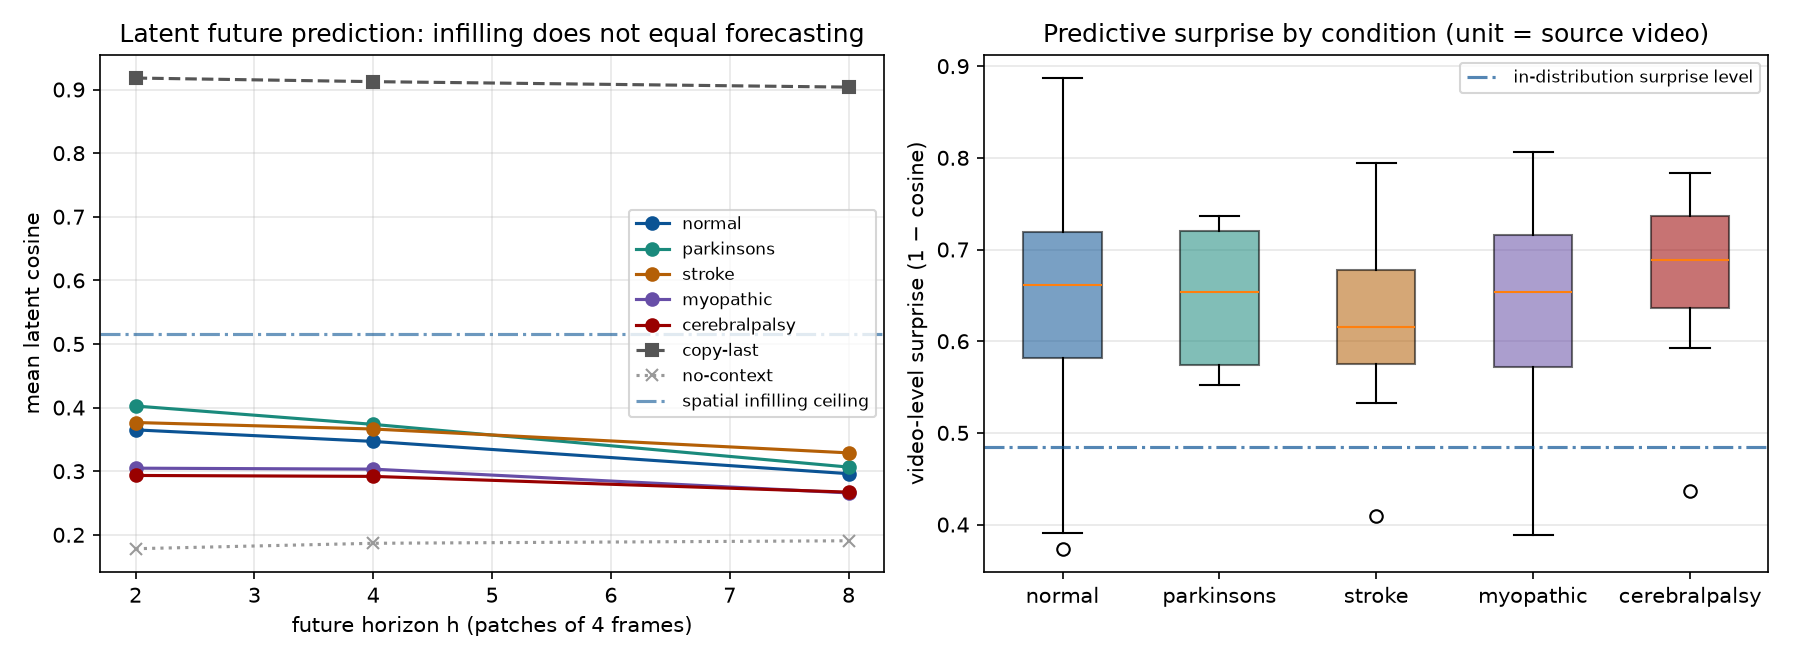

In [14]:
from IPython.display import Image, display

display(Image(filename="work/artifacts/real/predictive_surprise_summary.png"))

## What to read next

* `07_temporal_readout_diagnostic.ipynb` — the readout-vs-representation diagnostic (backup paper).
* `08_normal_anchor_drift_and_consolidation.ipynb` — quantified forgetting and the AnchorGuard repair
  (primary paper core).
* `docs/neurips-brain-body.md` — the full roadmap, claim discipline, and 72-hour plan.

**Research use only.** No diagnostic or clinical claims are made or implied.
